# Paper figures — sector counts, $D_{\max}$, and the sector-size distribution

Three final figures, built from the raw sweep records and **meant to be edited**.
Everything the figures draw is either loaded from `results/*.jsonl` or derived in
this notebook; no figure calls `qca_fragmentation.scaling.figure`, so you can
change any of it without touching the package.

| figure | file | what it shows |
|---|---|---|
| **1** | `fig_paper_sectors_obc0.pdf` | number of Krylov sectors vs $N$ — the R2 Fig. 1 content |
| **2** | `fig_paper_dmax_obc0.pdf` | largest sector $D_{\max}$ vs $N$ — same rules, same style |
| **1+2** | `fig_paper_scaling_obc0.pdf` | the two above as panels (a), (b) of one figure |
| **3** | `fig_paper_sizehist_obc0.pdf` | sector-size distribution for W156 and W108 |

**The claim Figures 1–2 make.** Three rules fragment *exponentially* — the number
of sectors grows like $a^N$ with $a>1$ — while two families fragment only
*polynomially*, into $\Theta(N)$ sectors that are individually huge. The contrast
is the whole point, so the two families are drawn with different line styles as
well as different hues.

**Every curve here is an exact integer law, not a fit.** §3 checks each one
against the data at every computed $N$ and raises if any has drifted, so the
annotations on the figures ($F_{N+2}$, $2^{N-1}$, …) are certified rather than
eyeballed.

## Editing this notebook

All the knobs are in §2 — sizes, fonts, palette, which rules appear, which $N$
the histograms use, output directory. The drawing code reads §2 and nothing
else, so in the common case you only edit §2 and re-run.

## 1 · Setup

In [1]:
import os, sys, json
from math import log10

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# the package lives in ../code relative to this notebook
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, os.path.join(ROOT, "code"))

from qca_fragmentation import results_io
from qca_fragmentation.core import rules as rules_mod
from qca_fragmentation.scaling.summary import load_series

BC = "obc0"          # pbc is held pending caveats -- see NEXT_STEPS.md
print("repo root:", results_io.REPO_ROOT)
print("matplotlib", mpl.__version__)

repo root: /home/mkmullenbach/Dokumente/Projects/QCA Simulations/Claude Sector Analysis/.claude/worktrees/tier1-analysis
matplotlib 3.9.2


## 2 · Knobs

Everything adjustable lives here.

**On the palette.** The five hues are the CVD-validated categorical order used
throughout the reports, re-checked with the `dataviz` validator over *all* pairs:
the worst separation is $\Delta E = 7.2$ (W201 green vs W156 red, protanopia),
which sits in the 6–8 band that is admissible *only* alongside a secondary
encoding. Three are present — distinct markers, a solid/dashed split by family,
and a direct law tag at each line end. The amber is at 2.11:1 against the
surface, below the 3:1 bar, which is the other reason W108 is labelled directly
instead of being left to the legend.

The histogram encodes $N$, which is an *ordered* quantity, so it uses a one-hue
light→dark ordinal ramp rather than categorical hues.

In [2]:
# ---- output -------------------------------------------------------------
OUT_DIR = os.path.join(ROOT, "figures", "paper")
os.makedirs(OUT_DIR, exist_ok=True)
SAVE_PNG = True          # PNG alongside every PDF, for quick viewing
PNG_DPI  = 300

# ---- page geometry (inches) ---------------------------------------------
COL   = 3.45             # single-column width of a two-column journal page
WIDE  = 7.0              # full-width
H1    = 2.75             # height of one scaling panel
HHIST = 2.35             # height of one histogram row

# ---- type ---------------------------------------------------------------
FS_TICK, FS_LABEL, FS_TITLE, FS_ANNOT, FS_LEGEND = 8, 9, 9.5, 7.5, 7.5

# ---- ink ----------------------------------------------------------------
TEXT, MUTED, GRID = "#0b0b0b", "#8a8a86", "#e6e6e2"

# ---- the rules, grouped into TRACKS -------------------------------------
# One track = one legend entry.  Rules inside a track share a hue because they
# share a law.  The extra rules are drawn FIRST as large open markers and the
# leading rule filled on top, so where the two coincide you see a dot inside a
# ring and where they part you see a lone ring -- a track that is really two
# curves never passes itself off as one.
TRACKS = [
    dict(key="156", rules=[156],      color="#e34948", marker="o", ls="-",
         label="W156 (IIVI)",  family="exponential"),
    dict(key="108", rules=[108],      color="#eda100", marker="s", ls="-",
         label="W108 (IIIV)",  family="exponential"),
    dict(key="201", rules=[201],      color="#008300", marker="^", ls="-",
         label="W201 (VIII)",  family="exponential"),
    dict(key="60",  rules=[60, 102],  color="#2a78d6", marker="D", ls="--",
         label="W60 = W102",   family="polynomial"),
    dict(key="150", rules=[150, 105], color="#4a3aa7", marker="v", ls="--",
         label="W150, W105",   family="polynomial"),
]

# Short law tags printed at the right-hand end of each curve; {} suppresses them.
LAW_TAG = {
    ("156", "n_recurrent"): r"$F_{N+2}$",
    ("108", "n_recurrent"): r"$\rho^{2N}$",
    ("201", "n_recurrent"): r"$\rho^{2N}$",
    ("60",  "n_recurrent"): r"$N+1$",
    ("150", "n_recurrent"): r"$\sim N/2$",
    ("156", "d_max"):       r"$4^{N/5}$",
    ("108", "d_max"):       r"$F_{N}$",
    ("201", "d_max"):       r"$F_{N+2}$",
    ("60",  "d_max"):       r"$2^{N-1}$",
    ("150", "d_max"):       r"$\binom{N+1}{w^{\ast}}$",
}

# Vertical nudges in points, for the few tags that would otherwise collide.
# W108 and W201 are the same sector law shifted by one site, so their curves
# run only a factor 1.75 apart -- close enough that the two tags touch.  In the
# D_max panel W60 ends at N=21 and W150 at N=22, which puts one tag on top of
# the other curve.
TAG_DY = {("108", "n_recurrent"): 5, ("201", "n_recurrent"): -5,
          ("150", "d_max"): 3, ("60", "d_max"): -8}

# The 2^N ceiling is informative on the D_max panel (W60/W102 sit exactly one
# factor of two below it) and merely stretches the axis on the sector panel.
SHOW_CEILING = {"n_recurrent": False, "d_max": True}
CEILING_LABEL_AT = -4    # index into the ceiling x-grid; -1 is the far end,
                         # which collides with the rightmost law tag

N_MAX_PLOT = None        # e.g. 16 to crop the x-range; None = everything

# ---- histogram ----------------------------------------------------------
HIST_RULES = [156, 108]
HIST_NS    = [13, 17, 21]                        # light -> dark
HIST_RAMP  = ["#86b6ef", "#2a78d6", "#104281"]   # one-hue ordinal ramp
# Log-spaced bins.  The sawtooth this leaves in the W156 panel is real, not
# noise: at small s a bin holds only one or two integer sizes, and even sizes
# are far commoner than odd ones.  Raising HIST_BINS sharpens it, lowering it
# averages the parities together.
HIST_BINS  = 22

## 3 · Data, and the exact laws behind every curve

`load_series` gives the two scaling series per rule; the raw record's
`size_hist` gives the **full** multiset of sector sizes.

One thing worth knowing before trusting Figure 3: for these rules the
`sizes_recurrent` list in the record is **truncated** at 2048 entries once
$N \ge 16$ (W108: $N \ge 14$), but `size_hist` is not — it carries every class,
and $\sum_s s\,h(s) = 2^N$ exactly. The loader asserts both, so a truncated
field cannot silently become a wrong histogram.

In [3]:
def series(rule):
    """The two scaling series for one rule; ergodic units already excluded."""
    s = load_series(rule, BC)
    return (np.array(s["N"]), np.array(s["n_recurrent"], float),
            np.array(s["d_max"], float))


def size_hist(rule, N):
    """{sector size -> how many sectors have it} for one (rule, N).

    Read from `size_hist`, which is complete even where `sizes_recurrent` is
    truncated.  The two asserts are what make that safe to rely on.
    """
    rec = results_io.load_results(rule, BC)[N]
    h = {int(k): int(v) for k, v in rec["size_hist"].items()}
    assert sum(h.values()) == rec["n_recurrent"], (rule, N, "class count")
    assert sum(s * c for s, c in h.items()) == 2 ** N, (rule, N, "mass")
    return h


for tr in TRACKS:
    for r in tr["rules"]:
        Ns, n, d = series(r)
        print(f"W{r:<4d} {''.join(rules_mod.wolfram_to_tuple(r))}  "
              f"N={Ns[0]}..{Ns[-1]}  n_wcc={int(n[-1]):>7d}  "
              f"D_max={int(d[-1]):>8d}")

W156  IIVI  N=6..21  n_wcc=  28657  D_max=     432
W108  IIIV  N=6..21  n_wcc= 170625  D_max=   10946
W201  VIII  N=6..21  n_wcc=  97229  D_max=   28657
W60   IIVV  N=6..21  n_wcc=     22  D_max= 1048576
W102  IVIV  N=6..21  n_wcc=     22  D_max= 1048576
W150  IVVI  N=6..22  n_wcc=     12  D_max= 1352078
W105  VIIV  N=6..21  n_wcc=     11  D_max=  705432


### The closed forms

Each was read off the integer series and then checked at **every** computed $N$,
not fitted. $F_k$ is the Fibonacci number with $F_1 = F_2 = 1$, and
$\rho^2 = 1.754878\ldots$ is the square of the plastic number — the dominant root
of $a_N = 2a_{N-1} - a_{N-2} + a_{N-3}$.

The two polynomial tracks are *not* degenerate pairs in the same way. W60 and
W102 agree term for term in both series, so that track is labelled with an
equals sign. W105 and W150 do not: at $N \equiv 1 \pmod 4$ — and at no other $N$
— W105's largest sector carries **odd** domain-wall number ($N=9$:
$\binom{10}{5} = 252$ against W150's $\binom{10}{4} = 210$) and it has one
sector fewer. One extra level of the wall number is exactly one fewer sector, so
that is a single phenomenon showing up in both panels. It is also why the track
is labelled `W150, W105` with a comma and drawn as two curves.

The laws themselves are *not* defined in this notebook — they are facts about
the data rather than design decisions, so they live in
`scaling/paper_figures.py`, where the test suite checks them independently of
anything drawn here. If you extend the sweep and a law breaks, the cell below
raises before a single figure is drawn.

In [4]:
from qca_fragmentation.scaling import paper_figures as PF

v = PF.verify(BC)
for (rule, key) in sorted(PF.LAWS, key=lambda t: (t[1], t[0])):
    c, name = v["laws"][(rule, key)], PF.LAWS[(rule, key)][1]
    print(f"{'ok  ' if c['ok'] else 'FAIL'} W{rule:<4d} {key:<12s} = {name}"
          + (f"   mismatch at N={c['mismatch']}" if c["mismatch"] else ""))
print(f"{'ok  ' if v['plastic_recurrence'] else 'FAIL'} W108  n_wcc obeys "
      f"a_N = 2a_(N-1) - a_(N-2) + a_(N-3), dominant root rho^2 = 1.754878")
print(f"{'ok  ' if v['shifted_partner'] else 'FAIL'} W201  "
      f"n_wcc(N) = W108 n_wcc(N-1) -- the same law, shifted by one site")
rb = v["room_base"]
print(f"ok   W156  D_max five-step ratio^(1/5) = {rb['estimate']:.7f}"
      f"  vs  4^(1/5) = {rb['target']:.7f}   (asymptotic, not exact -- see"
      f" the module docstring)")

assert v["ok"], [k for k, c in v["laws"].items() if not c["ok"]]
print("\nall closed forms hold at every computed N -- the figure tags are safe")

ok   W60   d_max        = 2^(N-1)
ok   W102  d_max        = 2^(N-1)
ok   W105  d_max        = max C(N+1,w), odd w at N=1 mod 4
ok   W108  d_max        = F_N
ok   W150  d_max        = max over even w of C(N+1,w)
ok   W201  d_max        = F_{N+2}
ok   W60   n_recurrent  = N+1
ok   W102  n_recurrent  = N+1
ok   W105  n_recurrent  = floor(N/2)+1+[N=3 mod 4]
ok   W150  n_recurrent  = floor((N+1)/2)+1
ok   W156  n_recurrent  = F_{N+2}
ok   W108  n_wcc obeys a_N = 2a_(N-1) - a_(N-2) + a_(N-3), dominant root rho^2 = 1.754878
ok   W201  n_wcc(N) = W108 n_wcc(N-1) -- the same law, shifted by one site
ok   W156  D_max five-step ratio^(1/5) = 1.3195079  vs  4^(1/5) = 1.3195079   (asymptotic, not exact -- see the module docstring)

all closed forms hold at every computed N -- the figure tags are safe


## 4 · Shared style

Recessive grid, no top/right spines, thin marks, direct labels. Nothing here is
figure-specific.

In [5]:
def panel_style(ax):
    ax.grid(True, color=GRID, linewidth=0.7)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(MUTED)
        ax.spines[s].set_linewidth(0.8)
    ax.tick_params(colors=MUTED, labelsize=FS_TICK, width=0.8, length=3)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.title.set_color(TEXT)


def save(fig, stem):
    pdf = os.path.join(OUT_DIR, f"{stem}_{BC}.pdf")
    fig.savefig(pdf, bbox_inches="tight")
    if SAVE_PNG:
        fig.savefig(pdf.replace(".pdf", ".png"), dpi=PNG_DPI,
                    bbox_inches="tight")
    print("wrote", os.path.relpath(pdf, ROOT))
    return pdf

## 5 · Figures 1 and 2 — sector count and $D_{\max}$ vs $N$

`scaling_panel` draws either series into a given axis, so Figure 1, Figure 2 and
the combined version are one piece of code called with a different `key`.

The $y$ axis is a true logarithmic axis with decade ticks rather than
$\ln(\cdot)$ plotted on a linear axis: the reader sees actual sector counts, and
a straight line still means an exponential.

In [6]:
def scaling_panel(ax, key, ylabel, title=None, legend=True, tags=True):
    """Draw one series (key = 'n_recurrent' or 'd_max') for every track."""
    panel_style(ax)
    xmax = 0
    for tr in TRACKS:
        # extras first (large, open), leading rule last (small, filled)
        order = list(enumerate(tr["rules"]))[::-1]
        for j, rule in order:
            Ns, n, d = series(rule)
            y = n if key == "n_recurrent" else d
            if N_MAX_PLOT:
                m = Ns <= N_MAX_PLOT
                Ns, y = Ns[m], y[m]
            first = (j == 0)
            ax.plot(Ns, y,
                    marker=tr["marker"], ms=3.6 if first else 5.6,
                    lw=1.4, ls=tr["ls"], color=tr["color"],
                    markerfacecolor=tr["color"] if first else "none",
                    markeredgecolor=tr["color"], markeredgewidth=0.9,
                    label=tr["label"] if (first and legend) else None,
                    zorder=4 if first else 3)
            xmax = max(xmax, int(Ns[-1]))
            if first and tags and LAW_TAG.get((tr["key"], key)):
                ax.annotate(LAW_TAG[(tr["key"], key)], (Ns[-1], y[-1]),
                            textcoords="offset points",
                            xytext=(5, TAG_DY.get((tr["key"], key), 0)),
                            fontsize=FS_ANNOT, color=tr["color"],
                            va="center", zorder=5)

    if SHOW_CEILING.get(key):
        xs = np.arange(6, xmax + 1)
        ax.plot(xs, 2.0 ** xs, color=MUTED, lw=0.7, ls=":", zorder=1)
        xa = xs[CEILING_LABEL_AT]
        ax.annotate(r"$2^N$", (xa, 2.0 ** xa),
                    textcoords="offset points", xytext=(-1, 6),
                    fontsize=FS_ANNOT, color=MUTED, ha="center", va="bottom")

    ax.set_yscale("log")
    # N is an integer; 7.5 sites is not a chain length
    ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
    ax.set_xlabel("chain length $N$", fontsize=FS_LABEL)
    ax.set_ylabel(ylabel, fontsize=FS_LABEL)
    if title:
        ax.set_title(title, fontsize=FS_TITLE, loc="left")
    ax.set_xlim(5, xmax + 3.4)
    if legend:
        ax.legend(frameon=False, fontsize=FS_LEGEND, loc="upper left",
                  handlelength=2.2, borderpad=0.1, labelspacing=0.25)
    return ax

wrote figures/paper/fig_paper_sectors_obc0.pdf


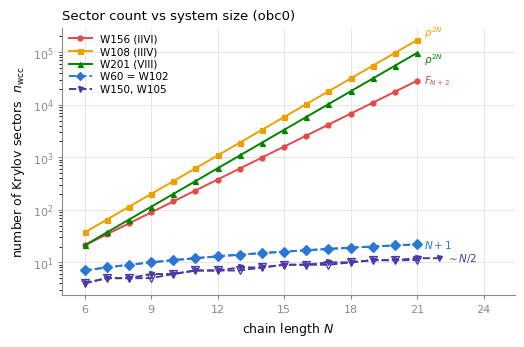

In [7]:
fig, ax = plt.subplots(figsize=(COL * 1.55, H1 * 1.3))
scaling_panel(ax, "n_recurrent",
              r"number of Krylov sectors  $n_{\mathrm{wcc}}$",
              title=f"Sector count vs system size ({BC})")
fig.tight_layout()
save(fig, "fig_paper_sectors")
plt.show()

wrote figures/paper/fig_paper_dmax_obc0.pdf


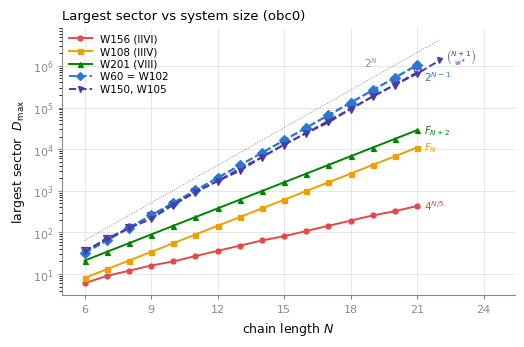

In [8]:
fig, ax = plt.subplots(figsize=(COL * 1.55, H1 * 1.3))
scaling_panel(ax, "d_max", r"largest sector  $D_{\max}$",
              title=f"Largest sector vs system size ({BC})")
fig.tight_layout()
save(fig, "fig_paper_dmax")
plt.show()

### The two as one figure

The panels are complementary — a rule high in (a) is low in (b), which is the
$n_{\mathrm{wcc}} \cdot D_{\max} \ge 2^N$ constraint showing up as a mirror — so
a paper usually wants them side by side. The legend goes in (a) only.

wrote figures/paper/fig_paper_scaling_obc0.pdf


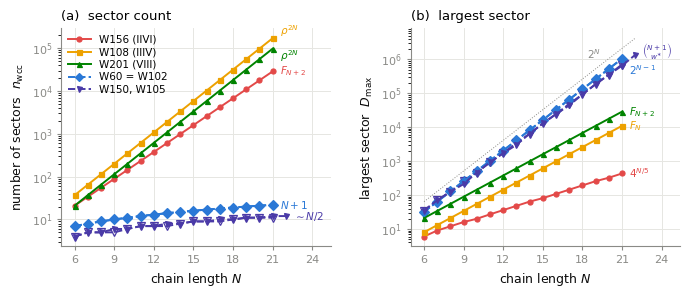

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(WIDE, H1 * 1.12))
scaling_panel(axes[0], "n_recurrent",
              r"number of sectors  $n_{\mathrm{wcc}}$",
              title="(a)  sector count", legend=True)
scaling_panel(axes[1], "d_max",
              r"largest sector  $D_{\max}$",
              title="(b)  largest sector", legend=False)
fig.tight_layout(w_pad=2.0)
save(fig, "fig_paper_scaling")
plt.show()

## 6 · Figure 3 — the sector-size distribution of W156 and W108

Two questions, one per row, for the two exponentially fragmented rules:

* **(top) how many sectors are there of each size?** Log-spaced bins, log
  counts — the shape of the fragmentation.
* **(bottom) where does a *random* product state end up?** The cumulative
  fraction of Hilbert space carried by sectors of size $\le s$. Read the median
  sector size off at $y = 0.5$.

The second row is the operationally meaningful one: the *typical* sector is much
smaller than $D_{\max}$, and the two rules differ far more in the typical size
than in the largest.

$N$ is ordered, so it is drawn as a single-hue light→dark ramp rather than three
categorical colours. The dashed vertical rule marks $D_{\max}$ at the largest
$N$ shown.

wrote figures/paper/fig_paper_sizehist_obc0.pdf


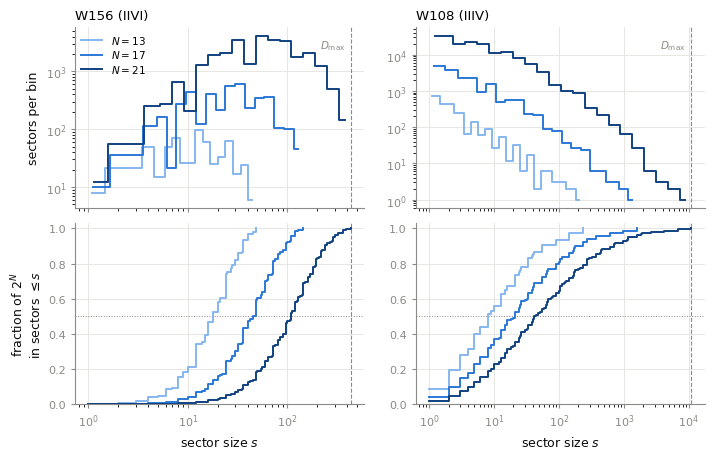

In [10]:
def hist_curves(rule, N, nbins=None):
    """Log-binned size distribution plus the exact cumulative-mass curve."""
    h = size_hist(rule, N)
    sizes = np.array(sorted(h), float)
    counts = np.array([h[int(s)] for s in sizes], float)

    edges = np.logspace(0, log10(sizes[-1]) + 1e-9, (nbins or HIST_BINS) + 1)
    idx = np.clip(np.digitize(sizes, edges) - 1, 0, len(edges) - 2)
    binned = np.zeros(len(edges) - 1)
    np.add.at(binned, idx, counts)
    centres = np.sqrt(edges[:-1] * edges[1:])

    mass = sizes * counts / 2.0 ** N          # fraction of Hilbert space
    return dict(centres=centres, binned=binned,
                sizes=sizes, cum=np.cumsum(mass),
                d_max=sizes[-1], n_sec=counts.sum(),
                mean=2.0 ** N / counts.sum())


fig, axes = plt.subplots(2, len(HIST_RULES),
                         figsize=(COL * 1.05 * len(HIST_RULES), HHIST * 2),
                         sharex="col")
axes = np.atleast_2d(axes)

for c, rule in enumerate(HIST_RULES):
    top, bot = axes[0, c], axes[1, c]
    panel_style(top)
    panel_style(bot)

    for k, N in enumerate(HIST_NS):
        col = HIST_RAMP[k % len(HIST_RAMP)]
        cu = hist_curves(rule, N)
        nz = cu["binned"] > 0
        top.step(cu["centres"][nz], cu["binned"][nz], where="mid",
                 color=col, lw=1.4, label=f"$N={N}$", zorder=3)
        bot.step(cu["sizes"], cu["cum"], where="post",
                 color=col, lw=1.4, label=f"$N={N}$", zorder=3)

    last = hist_curves(rule, HIST_NS[-1])
    for ax in (top, bot):
        ax.axvline(last["d_max"], color=MUTED, lw=0.8, ls="--", zorder=1)
        ax.set_xscale("log")
    top.annotate(r"$D_{\max}$", (last["d_max"], 1.0),
                 xycoords=("data", "axes fraction"),
                 textcoords="offset points", xytext=(-4, -8),
                 ha="right", va="top", fontsize=FS_ANNOT, color=MUTED)

    top.set_yscale("log")
    top.set_title(f"W{rule} ({''.join(rules_mod.wolfram_to_tuple(rule))})",
                  fontsize=FS_TITLE, loc="left")
    bot.set_ylim(0, 1.03)
    bot.set_xlabel("sector size $s$", fontsize=FS_LABEL)
    bot.axhline(0.5, color=MUTED, lw=0.7, ls=":", zorder=1)

    if c == 0:
        top.set_ylabel("sectors per bin", fontsize=FS_LABEL)
        bot.set_ylabel("fraction of $2^N$\nin sectors $\\leq s$",
                       fontsize=FS_LABEL)
        # upper LEFT: the D_max rule and its label own the top right corner
        top.legend(frameon=False, fontsize=FS_LEGEND, loc="upper left",
                   labelspacing=0.25, borderpad=0.1)

fig.tight_layout(w_pad=1.6, h_pad=0.8)
save(fig, "fig_paper_sizehist")
plt.show()

### The numbers behind Figure 3

Worth quoting in a caption. $D_{\max}/2^N$ is the largest fraction of Hilbert
space any one sector holds; the median is the size of the sector a uniformly
random computational-basis state lands in.

In [11]:
# PF.size_stats is the same arithmetic, in the package, so the report table and
# this cell cannot disagree.
print(f"{'rule':>5} {'N':>3} {'sectors':>9} {'D_max':>8} {'D_max/2^N':>11}"
      f" {'mean':>8} {'median':>8} {'singletons':>11}")
for rule in HIST_RULES:
    for N in HIST_NS:
        s = PF.size_stats(rule, N, BC)
        print(f"{rule:>5} {N:>3} {s['n_sectors']:>9} {s['d_max']:>8}"
              f" {s['d_max_fraction']:>11.3e} {s['mean']:>8.2f}"
              f" {s['median']:>8} {s['n_singletons']:>11}")

 rule   N   sectors    D_max   D_max/2^N     mean   median  singletons
  156  13       610       48   5.859e-03    13.43       18           8
  156  17      4181      144   1.099e-03    31.35       45          10
  156  21     28657      432   2.060e-04    73.18      108          12
  108  13      1897      233   2.844e-02     4.32        8         714
  108  17     17991     1597   1.218e-02     7.29       21        4895
  108  21    170625    10946   5.219e-03    12.29       42       33552


## 7 · Caveats

* **`obc0` only.** The `pbc` sweep is held pending caveats (`NEXT_STEPS.md`), and
  at odd $N$ under `pbc` the brick-wall layers stop commuting, so those points
  would need even $N$ only.
* **These are WCC sectors**, which for the unitary rules shown coincide with the
  strongly connected components, so the decomposition is exact for the monitored
  and the unmonitored chain alike. That equality is a property of *unitarity*
  and does not carry over to the dissipative rules.
* **W198 is W156 under reflection** and W108/W201 are spin-flip partners, so each
  figure shows one representative and the partner is omitted rather than drawn
  on top of its twin.
* **`sizes_recurrent` is truncated** at 2048 entries in the records for
  $N \ge 16$ (W108: $N \ge 14$). Figure 3 reads `size_hist`, which is not, and §3
  asserts the mass sums to $2^N$ so the distinction cannot be forgotten.
* **The law tags are exact, and §3 is what makes them so.** If a future sweep
  extends the $N$ range and a law breaks, §3 raises before any figure is drawn.